□ Télécharger le Data Capsule
□ Regarder describe() sur chaque produit
□ Tracer les mid prices
□ Identifier : mean reversion ou trend ?
□ Adapter le trader.py
□ Backtest local
□ Soumettre

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import glob

In [3]:
ROUND = 1  # changer à chaque round

# Charger tous les jours disponibles
price_files = sorted(glob.glob(f"data/prices_round_{ROUND}_day_*.csv"))
trade_files = sorted(glob.glob(f"data/trades_round_{ROUND}_day_*.csv"))

prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files]).reset_index(drop=True)
trades = pd.concat([pd.read_csv(f, sep=";") for f in trade_files]).reset_index(drop=True)

products = prices["product"].unique()
print(f"Produits : {products}")
print(f"Ticks : {len(prices)}")
print(f"Trades : {len(trades)}")

Produits : ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
Ticks : 60000
Trades : 2276


In [4]:
for product in products:
    p = prices[prices["product"] == product]["mid_price"]
    print(f"\n{'='*40}")
    print(f"  {product}")
    print(f"{'='*40}")
    print(p.describe().round(2))
    print(f"  Range   : {p.max() - p.min():.2f}")
    print(f"  Std/Mean: {(p.std()/p.mean()*100):.3f}%  (volatilité relative)")


  INTARIAN_PEPPER_ROOT
count    30000.00
mean     11479.19
std        993.18
min          0.00
25%      10745.50
50%      11497.50
75%      12248.50
max      13007.00
Name: mid_price, dtype: float64
  Range   : 13007.00
  Std/Mean: 8.652%  (volatilité relative)

  ASH_COATED_OSMIUM
count    30000.00
mean      9983.87
std        403.87
min          0.00
25%       9997.00
50%      10000.50
75%      10003.50
max      10023.00
Name: mid_price, dtype: float64
  Range   : 10023.00
  Std/Mean: 4.045%  (volatilité relative)


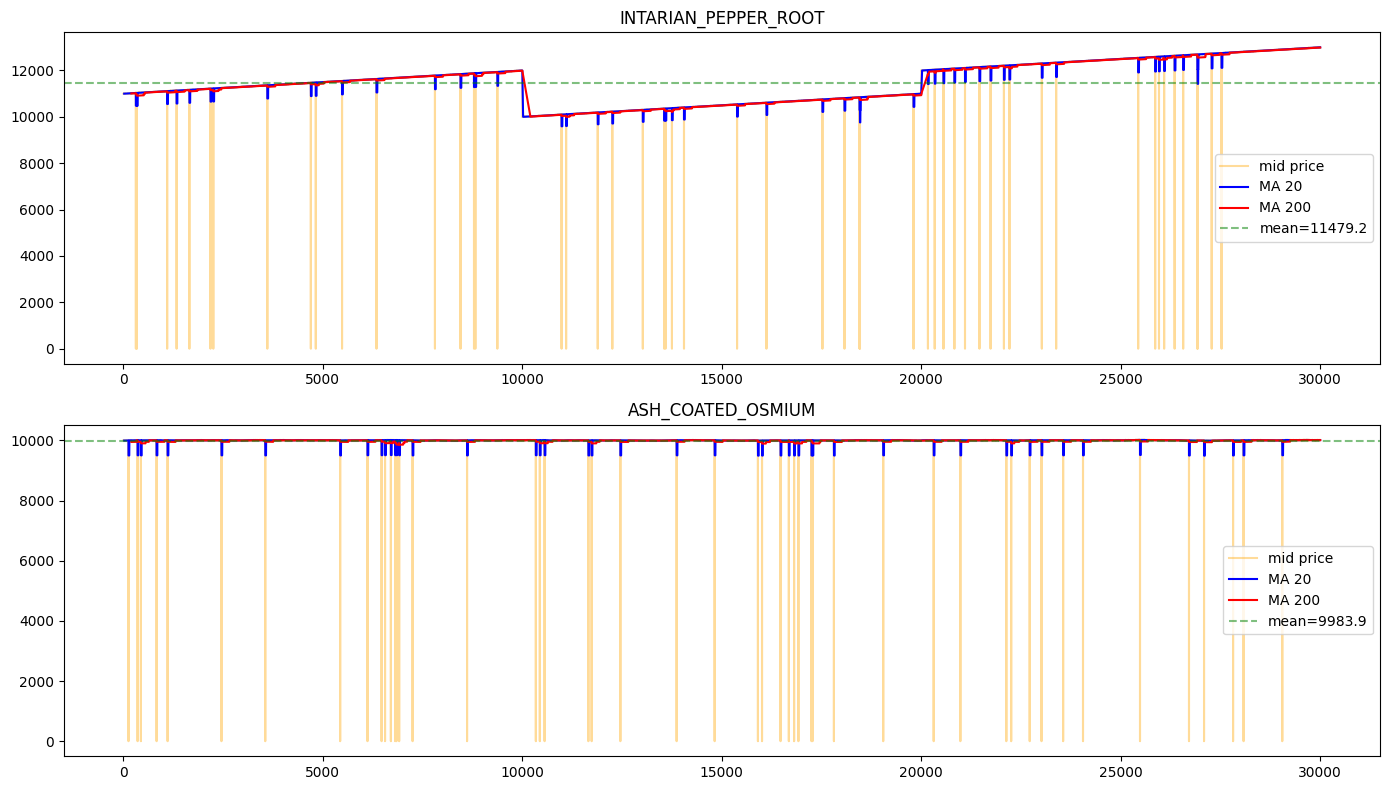

In [5]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    p = prices[prices["product"] == product]["mid_price"].reset_index(drop=True)
    
    ma20  = p.rolling(20).mean()
    ma200 = p.rolling(200).mean()
    
    ax.plot(p,     alpha=0.4, label="mid price", color="orange")
    ax.plot(ma20,  label="MA 20",  color="blue",  linewidth=1.5)
    ax.plot(ma200, label="MA 200", color="red",   linewidth=1.5)
    ax.axhline(p.mean(), color="green", linestyle="--", alpha=0.5, label=f"mean={p.mean():.1f}")
    ax.set_title(product)
    ax.legend()

plt.tight_layout()
plt.show()


========================================  INTARIAN_PEPPER_ROOT
Empty DataFrame
Columns: [buyer, seller]
Index: []

Top acheteurs :
Series([], Name: quantity, dtype: int64)

Top vendeurs  :
Series([], Name: quantity, dtype: int64)


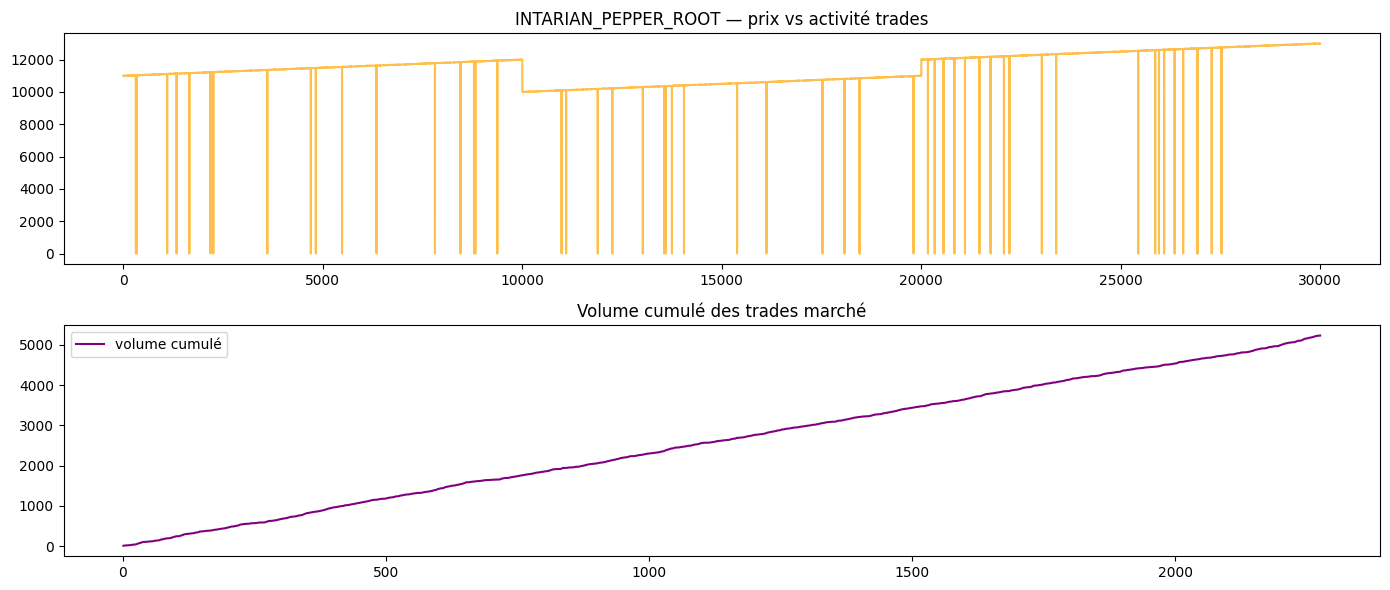


========================================  ASH_COATED_OSMIUM
Empty DataFrame
Columns: [buyer, seller]
Index: []

Top acheteurs :
Series([], Name: quantity, dtype: int64)

Top vendeurs  :
Series([], Name: quantity, dtype: int64)


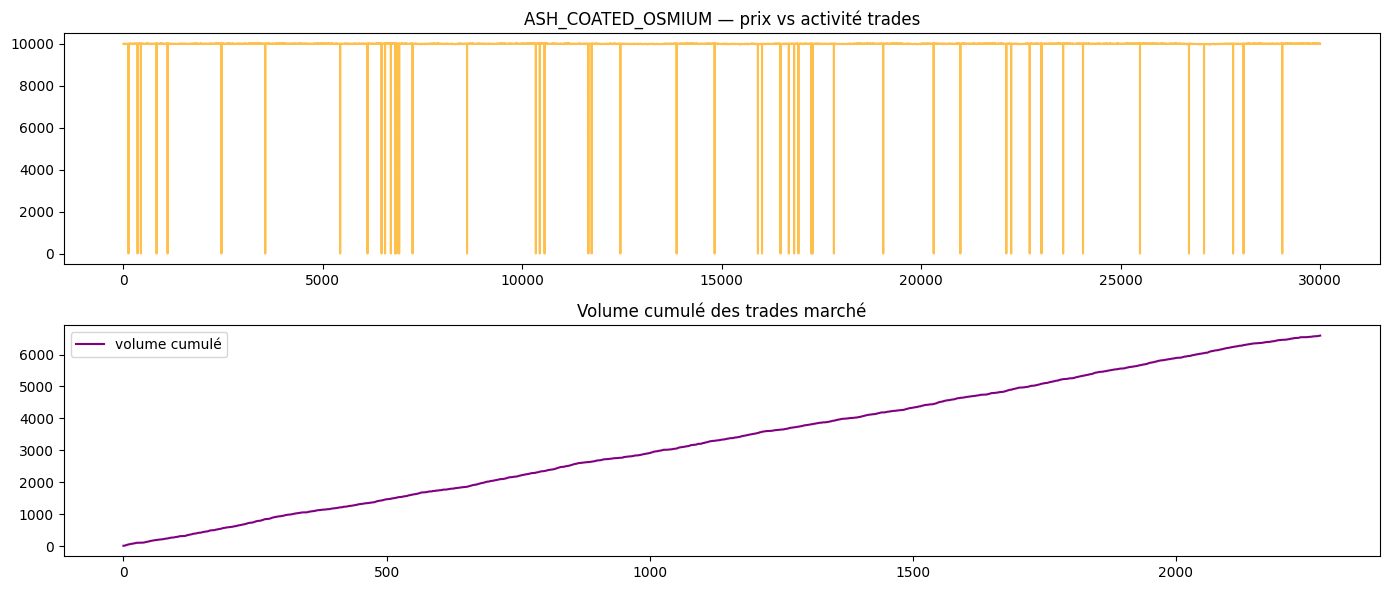

In [6]:
# --- Innovation 1 : que font les autres bots ? ---
for product in products:
    t = trades[trades["symbol"] == product].copy()
    if t.empty:
        print(f"{product} : pas de trades")
        continue

    print(f"\n{'='*40}  {product}")
    print(t[["buyer","seller"]].apply(pd.Series.value_counts).fillna(0))
    
    # Qui sont les acheteurs nets ? (signal directionnel)
    buyers  = t.groupby("buyer")["quantity"].sum().sort_values(ascending=False)
    sellers = t.groupby("seller")["quantity"].sum().sort_values(ascending=False)
    print(f"\nTop acheteurs :\n{buyers.head()}")
    print(f"\nTop vendeurs  :\n{sellers.head()}")

    # Pression acheteur vs vendeur dans le temps
    t["buy_pressure"] = t["quantity"]   # trades initiés par acheteurs
    p_data = prices[prices["product"] == product]["mid_price"].reset_index(drop=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
    p_data.plot(ax=ax1, color="orange", alpha=0.7, title=f"{product} — prix vs activité trades")
    
    t["quantity"].cumsum().plot(ax=ax2, color="purple", label="volume cumulé")
    ax2.set_title("Volume cumulé des trades marché")
    ax2.legend()
    plt.tight_layout()
    plt.show()

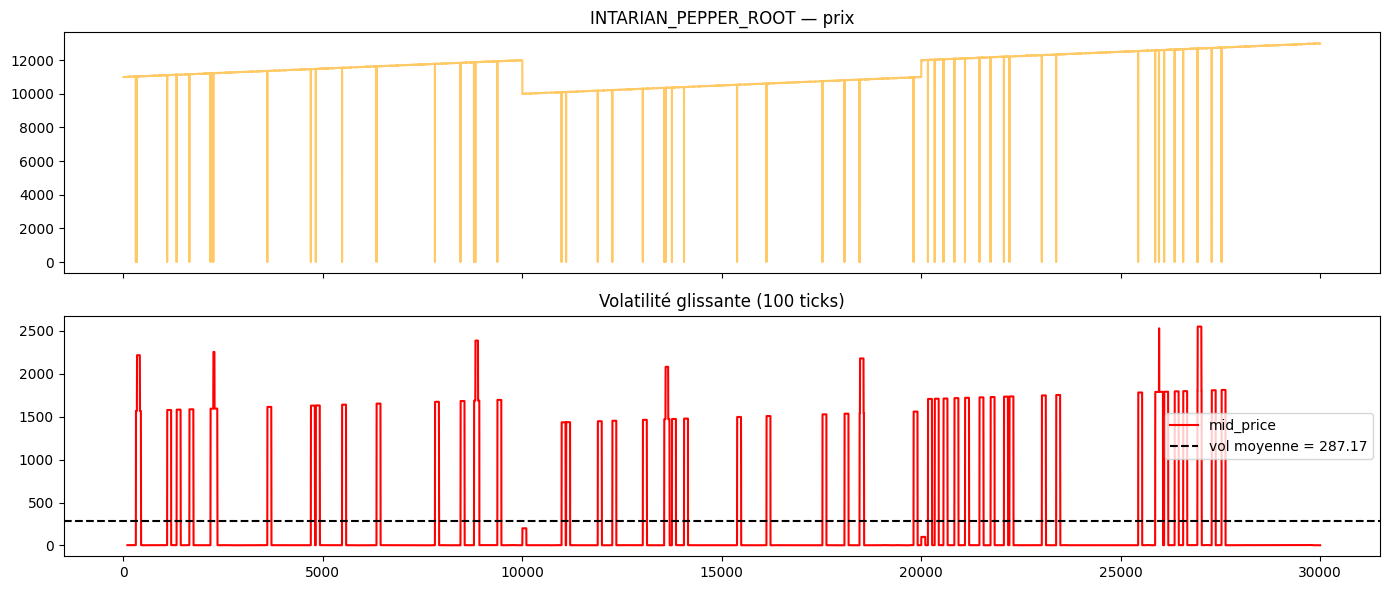

INTARIAN_PEPPER_ROOT → haute vol : 16.7% du temps | basse vol : 82.6% du temps


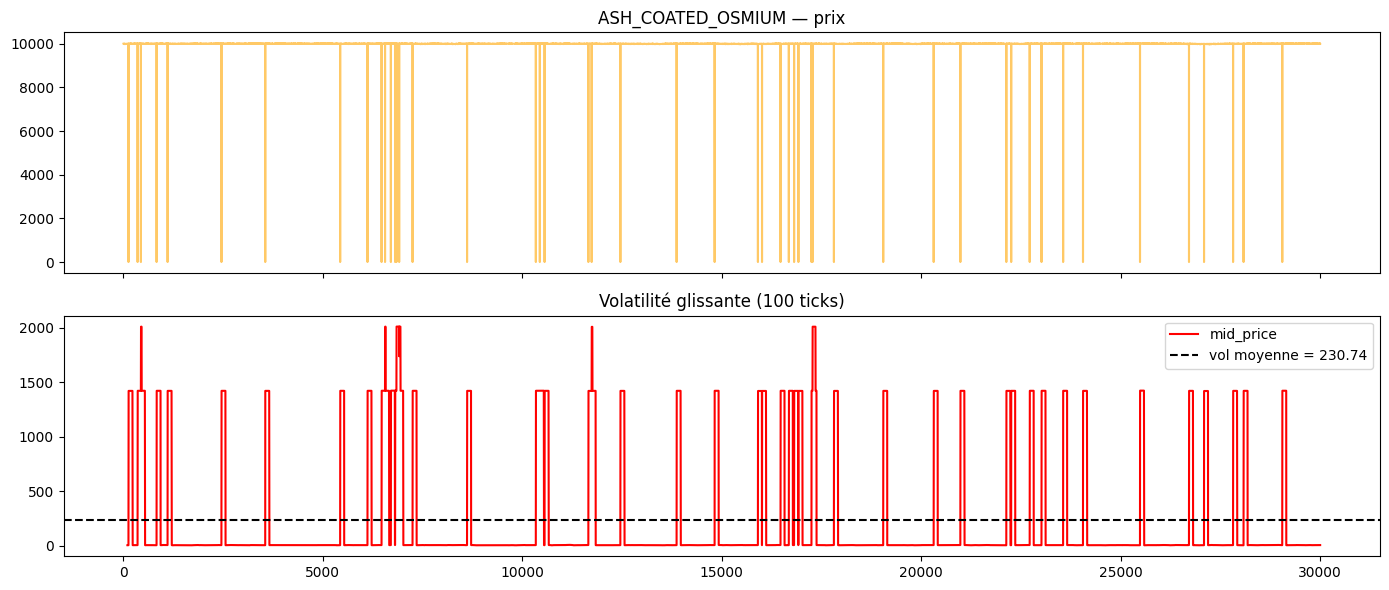

ASH_COATED_OSMIUM → haute vol : 15.7% du temps | basse vol : 83.9% du temps


In [7]:
# --- Innovation 2 : la volatilité change-t-elle dans le temps ? ---
for product in products:
    p = prices[prices["product"] == product]["mid_price"].reset_index(drop=True)
    returns = p.diff()
    
    # Volatilité glissante sur 100 ticks
    vol_rolling = returns.rolling(100).std()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    p.plot(ax=ax1, color="orange", alpha=0.6, title=f"{product} — prix")
    vol_rolling.plot(ax=ax2, color="red", title="Volatilité glissante (100 ticks)")
    ax2.axhline(vol_rolling.mean(), color="black", linestyle="--", label=f"vol moyenne = {vol_rolling.mean():.2f}")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    # Régimes de volatilité
    vol_mean = vol_rolling.mean()
    high_vol = (vol_rolling > vol_mean * 1.5).mean()
    low_vol  = (vol_rolling < vol_mean * 0.5).mean()
    print(f"{product} → haute vol : {high_vol:.1%} du temps | basse vol : {low_vol:.1%} du temps")


========================================  INTARIAN_PEPPER_ROOT
Spread moyen : 13.05  |  max : 21
Imbalance moyen : -0.003  (>0 = pression acheteur)


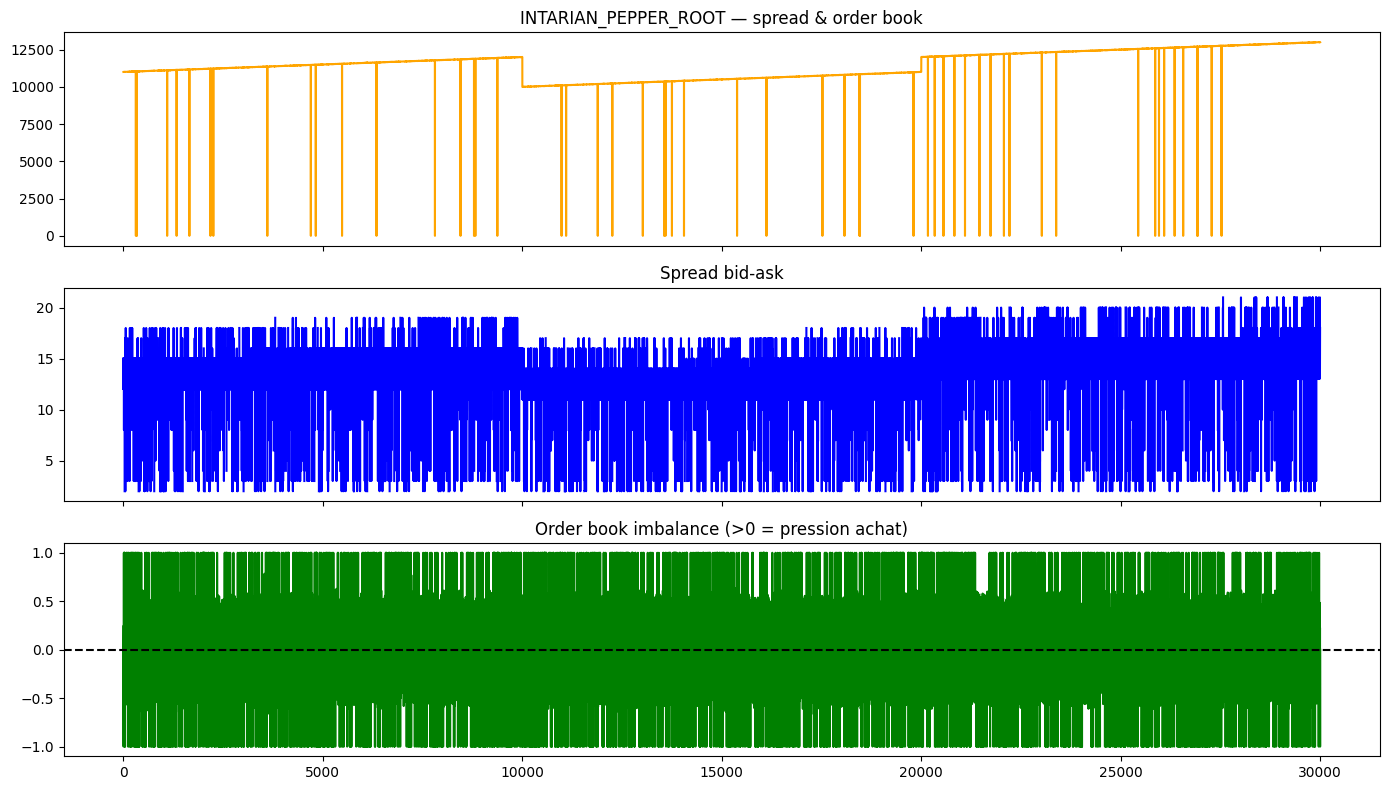


========================================  ASH_COATED_OSMIUM
Spread moyen : 16.18  |  max : 22
Imbalance moyen : -0.001  (>0 = pression acheteur)


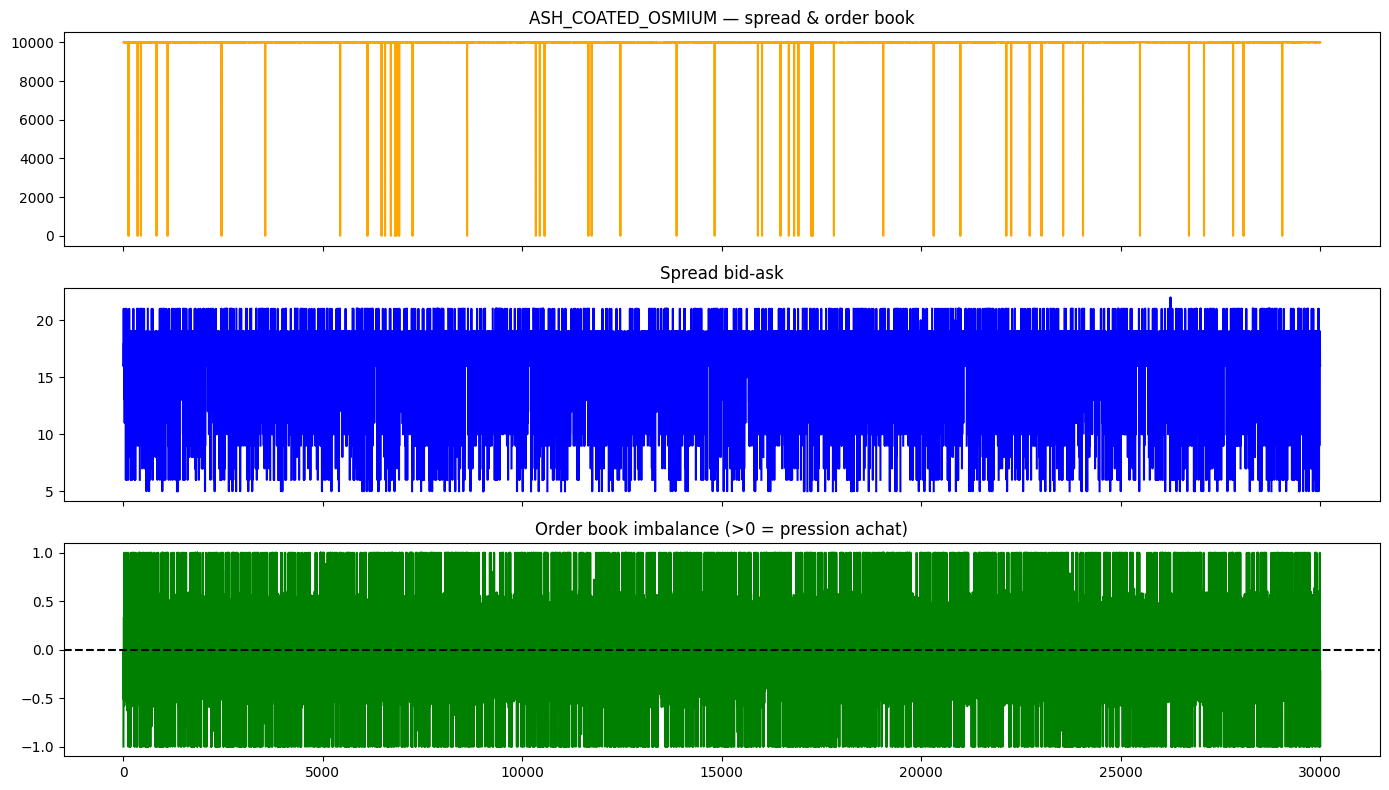

In [8]:
# --- Innovation 3 : est-ce que le spread varie ? quand être agressif ? ---
for product in products:
    p = prices[prices["product"] == product].copy().reset_index(drop=True)
    
    p["spread"] = p["ask_price_1"] - p["bid_price_1"]
    p["depth_bid"] = p["bid_volume_1"].fillna(0) + p["bid_volume_2"].fillna(0) + p["bid_volume_3"].fillna(0)
    p["depth_ask"] = p["ask_volume_1"].fillna(0) + p["ask_volume_2"].fillna(0) + p["ask_volume_3"].fillna(0)
    p["imbalance"] = (p["depth_bid"] - p["depth_ask"]) / (p["depth_bid"] + p["depth_ask"])

    print(f"\n{'='*40}  {product}")
    print(f"Spread moyen : {p['spread'].mean():.2f}  |  max : {p['spread'].max():.0f}")
    print(f"Imbalance moyen : {p['imbalance'].mean():.3f}  (>0 = pression acheteur)")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    p["mid_price"].plot(ax=axes[0], color="orange", title=f"{product} — spread & order book")
    p["spread"].plot(ax=axes[1], color="blue", title="Spread bid-ask")
    p["imbalance"].plot(ax=axes[2], color="green", title="Order book imbalance (>0 = pression achat)")
    axes[2].axhline(0, color="black", linestyle="--")
    plt.tight_layout()
    plt.show()

In [9]:
# --- Résumé pour décider la stratégie par produit ---
print("SYNTHÈSE\n" + "="*50)
for product in products:
    p = prices[prices["product"] == product]["mid_price"]
    returns = p.diff()
    autocorr_short = returns.autocorr(lag=10)
    autocorr_long  = returns.autocorr(lag=500)
    vol = returns.std()
    spread_mean = (prices[prices["product"] == product]["ask_price_1"] - 
                   prices[prices["product"] == product]["bid_price_1"]).mean()
    
    # Diagnostic automatique
    if abs(p.std() / p.mean()) < 0.001:
        regime = "MEAN REVERSION FORTE (type Emeralds)"
    elif autocorr_short > 0.1:
        regime = "TREND / MOMENTUM"
    elif autocorr_long < -0.1:
        regime = "MEAN REVERSION LENTE (type Tomatoes)"
    else:
        regime = "MIXTE — analyser manuellement"
    
    print(f"\n{product}")
    print(f"  Régime     : {regime}")
    print(f"  Volatilité : {vol:.3f}")
    print(f"  Spread moy : {spread_mean:.1f}")
    print(f"  Autocorr 10: {autocorr_short:.3f}")
    print(f"  Autocorr 500:{autocorr_long:.3f}")
    print(f"  → Stratégie suggérée : ", end="")
    
    if "FORTE" in regime:
        print("Market making tight autour de la fair value fixe")
    elif "TREND" in regime:
        print("Momentum — suivre la direction, market making avec biais")
    elif "LENTE" in regime:
        print("Double MA avec biais directionnel")
    else:
        print("À déterminer manuellement")

SYNTHÈSE

INTARIAN_PEPPER_ROOT
  Régime     : MIXTE — analyser manuellement
  Volatilité : 693.864
  Spread moy : 13.0
  Autocorr 10: -0.008
  Autocorr 500:0.000
  → Stratégie suggérée : À déterminer manuellement

ASH_COATED_OSMIUM
  Régime     : MIXTE — analyser manuellement
  Volatilité : 571.658
  Spread moy : 16.2
  Autocorr 10: -0.000
  Autocorr 500:0.000
  → Stratégie suggérée : À déterminer manuellement


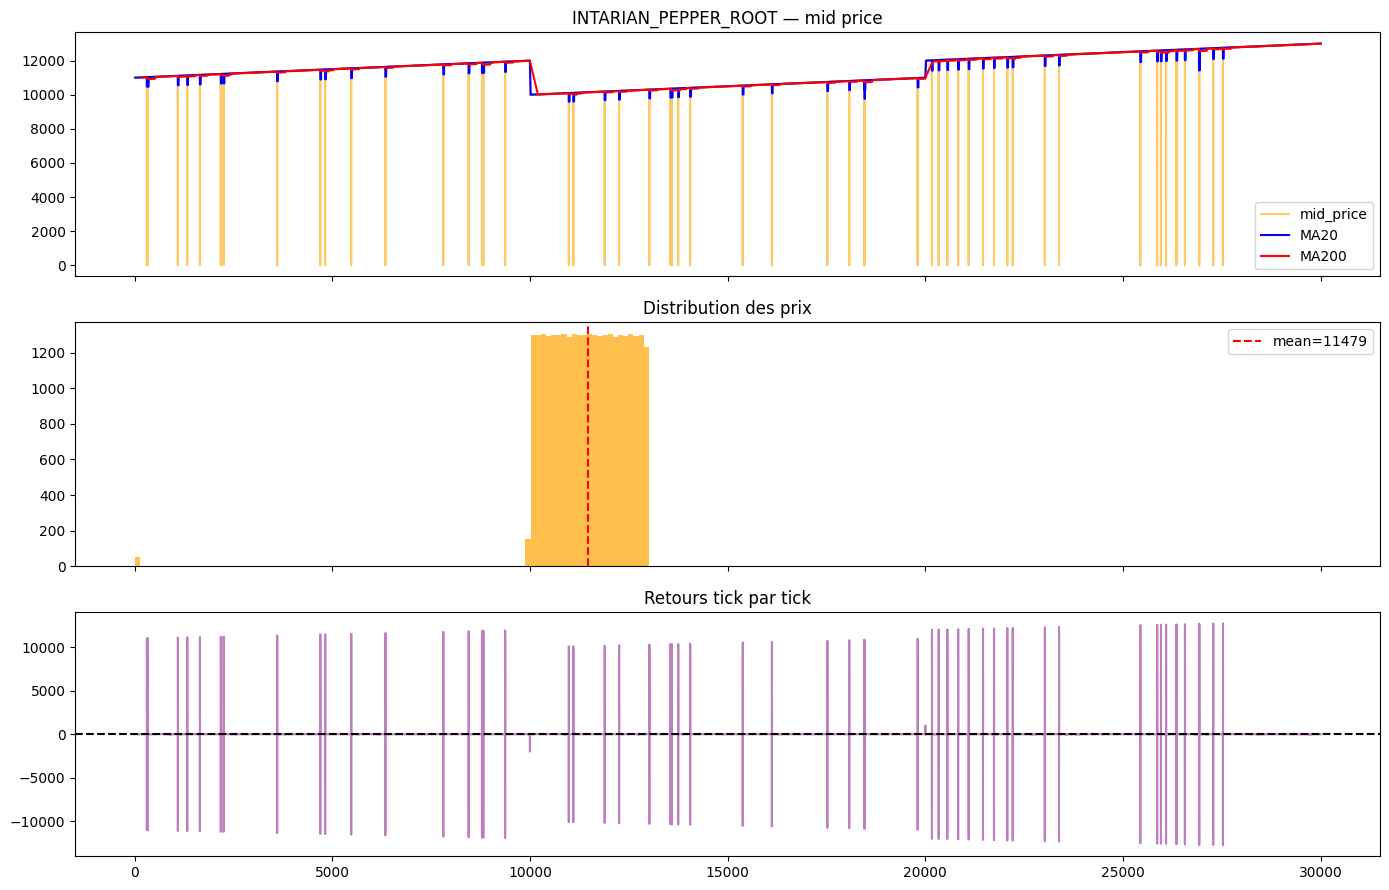

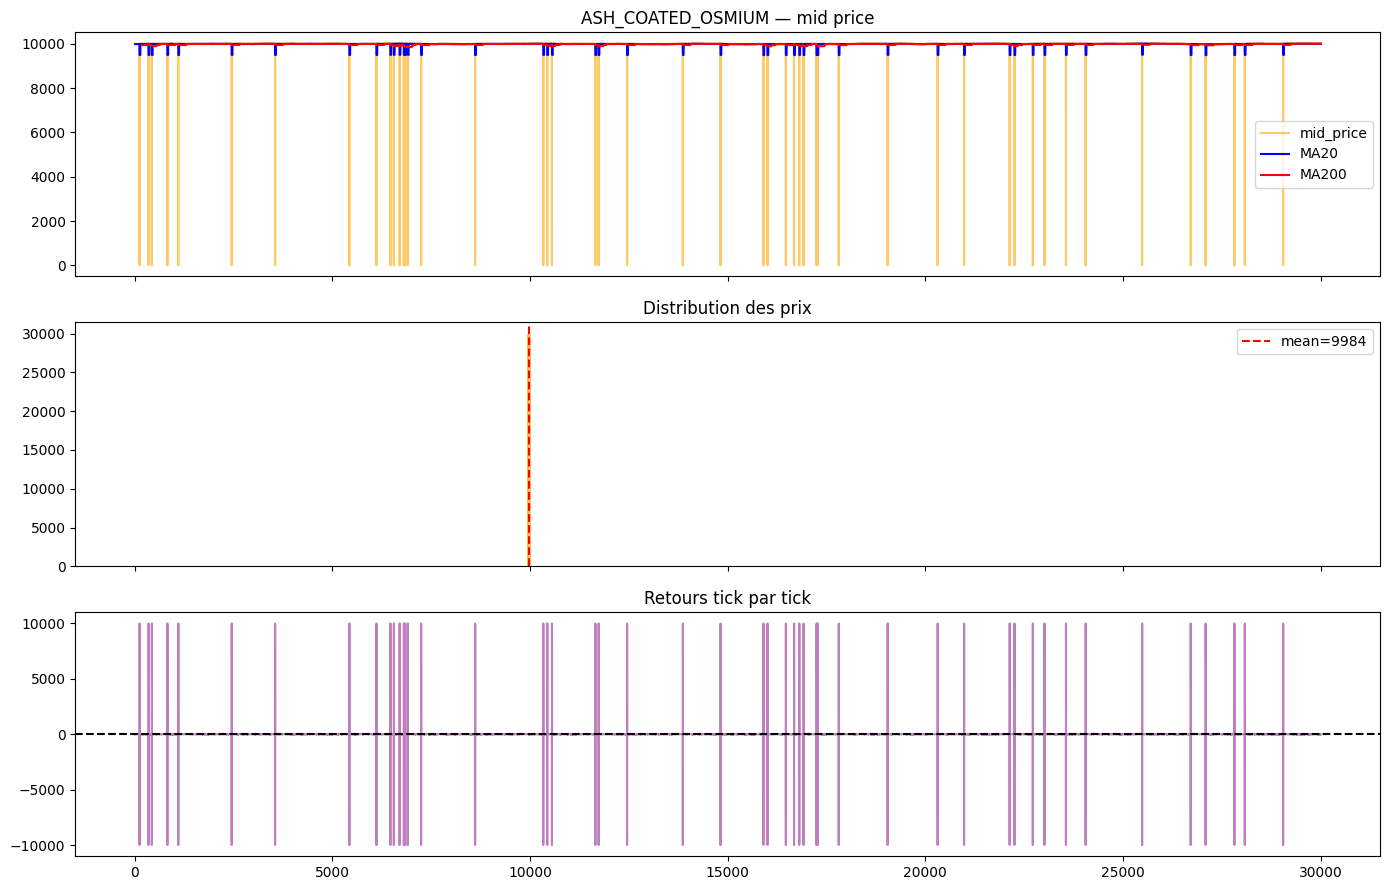

In [10]:
for product in products:
    p = prices[prices["product"] == product]["mid_price"].reset_index(drop=True)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    
    # Prix brut
    p.plot(ax=axes[0], color="orange", alpha=0.6, title=f"{product} — mid price")
    p.rolling(20).mean().plot(ax=axes[0], color="blue", label="MA20")
    p.rolling(200).mean().plot(ax=axes[0], color="red", label="MA200")
    axes[0].legend()
    
    # Distribution des prix
    axes[1].hist(p, bins=100, color="orange", alpha=0.7)
    axes[1].axvline(p.mean(), color="red", linestyle="--", label=f"mean={p.mean():.0f}")
    axes[1].set_title("Distribution des prix")
    axes[1].legend()
    
    # Retours tick par tick
    returns = p.diff()
    returns.plot(ax=axes[2], color="purple", alpha=0.5, title="Retours tick par tick")
    axes[2].axhline(0, color="black", linestyle="--")
    
    plt.tight_layout()
    plt.show()

In [11]:
# Filtrer les mid_price aberrants
prices_clean = prices[prices["mid_price"] > prices.groupby("product")["mid_price"].transform(lambda x: x.quantile(0.01))]

# Vérifier
for product in products:
    p = prices_clean[prices_clean["product"] == product]["mid_price"]
    print(f"{product}: min={p.min():.0f} max={p.max():.0f} mean={p.mean():.0f}")

INTARIAN_PEPPER_ROOT: min=10025 max=13007 mean=11512
ASH_COATED_OSMIUM: min=9988 max=10023 mean=10000


In [12]:
osm = prices_clean[prices_clean["product"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)

# Les vrais prix filtrés sont entre 9988 et 10023
# Mais regardons AVANT le filtre — les spikes ont-ils un pattern ?
osm_raw = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)
spikes = osm_raw[osm_raw["mid_price"] < 9000]
print(f"Nombre de spikes : {len(spikes)}")
print(f"Timestamps des spikes :\n{spikes['timestamp'].values[:20]}")

# Est-ce que les spikes sont régulièrement espacés ?
if len(spikes) > 1:
    gaps = spikes["timestamp"].diff().dropna()
    print(f"\nEcarts entre spikes :")
    print(gaps.describe())
    print(f"Ecarts uniques : {gaps.value_counts().head(10)}")

Nombre de spikes : 49
Timestamps des spikes :
[ 12700  35500  43800  83100 110700 245700 355500 543300 611800 647100
 655800 670400 681100 684400 691200 724800 861400  33800  43800  55700]

Ecarts entre spikes :
count        48.000000
mean      18587.500000
std      189351.418903
min     -873500.000000
25%       11625.000000
50%       36500.000000
75%       95725.000000
max      187800.000000
Name: timestamp, dtype: float64
Ecarts uniques : timestamp
46400.0     2
109800.0    2
115200.0    1
20800.0     1
13200.0     1
10800.0     1
32800.0     1
2600.0      1
53600.0     1
123600.0    1
Name: count, dtype: int64


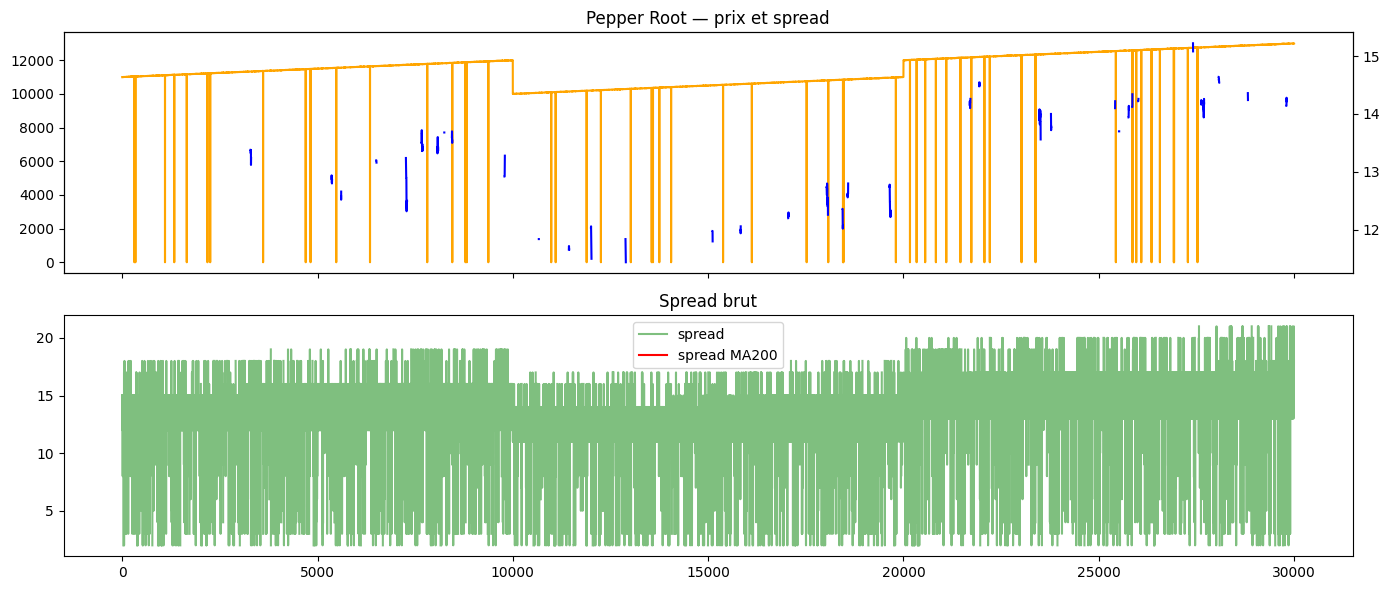

Corrélation spread/prix : 0.349
count    27688.000000
mean        13.046699
std          2.627145
min          2.000000
25%         12.000000
50%         13.000000
75%         14.000000
max         21.000000
Name: spread, dtype: float64


In [13]:
pepper = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)
pepper["spread"] = pepper["ask_price_1"] - pepper["bid_price_1"]

# Spread dans le temps
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
pepper["mid_price"].plot(ax=ax1, color="orange", title="Pepper Root — prix et spread")
pepper["spread"].rolling(50).mean().plot(ax=ax1, color="blue", secondary_y=True, label="spread MA50")
pepper["spread"].plot(ax=ax2, color="green", alpha=0.5, title="Spread brut")
pepper["spread"].rolling(200).mean().plot(ax=ax2, color="red", label="spread MA200")
ax2.legend()
plt.tight_layout()
plt.show()

# Corrélation spread / prix
corr = pepper["spread"].corr(pepper["mid_price"])
print(f"Corrélation spread/prix : {corr:.3f}")
print(pepper["spread"].describe())